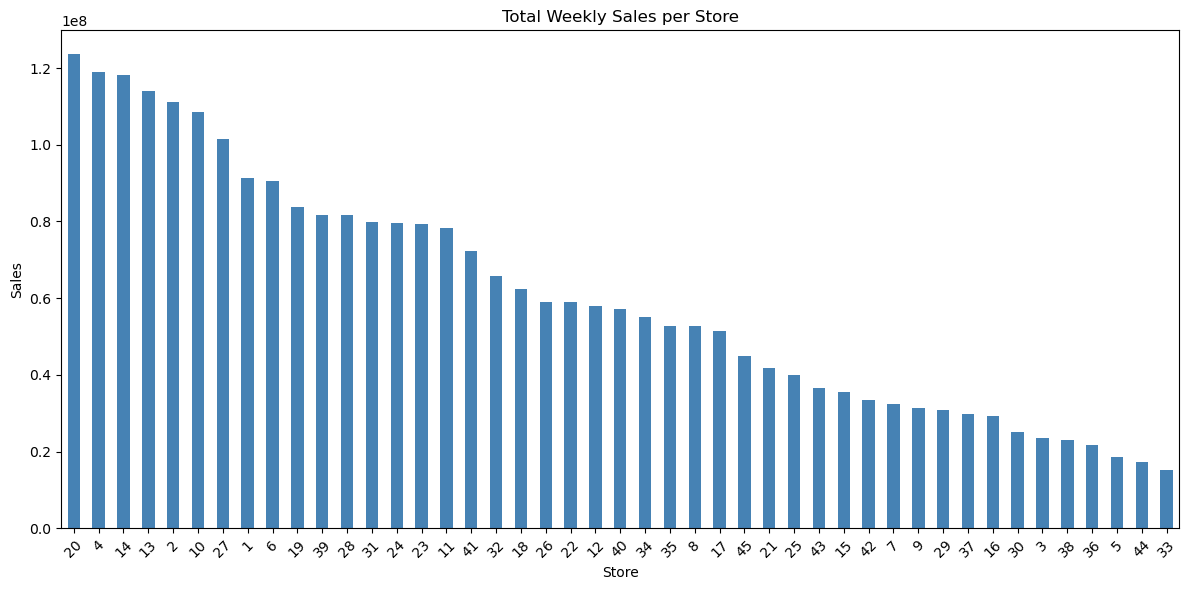

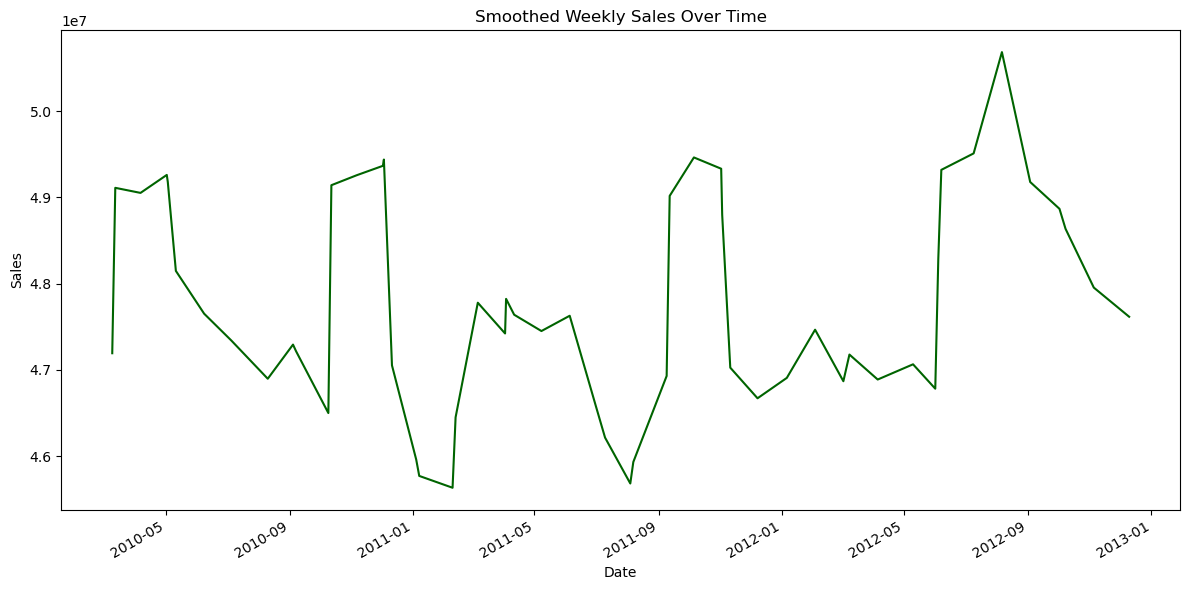

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean
df = pd.read_csv('walmart-sales-dataset-of-45stores.csv')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.dropna(subset=['Date'], inplace=True)

# Total and average sales per store
store_sales = df.groupby('Store')['Weekly_Sales'].agg(['sum', 'mean']).sort_values(by='sum', ascending=False)

plt.figure(figsize=(12,6))
store_sales['sum'].plot(kind='bar', color='steelblue')
plt.title('Total Weekly Sales per Store')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Weekly sales over time
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(12,6))
weekly_sales.rolling(window=4).mean().plot(color='darkgreen')
plt.title('Smoothed Weekly Sales Over Time')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

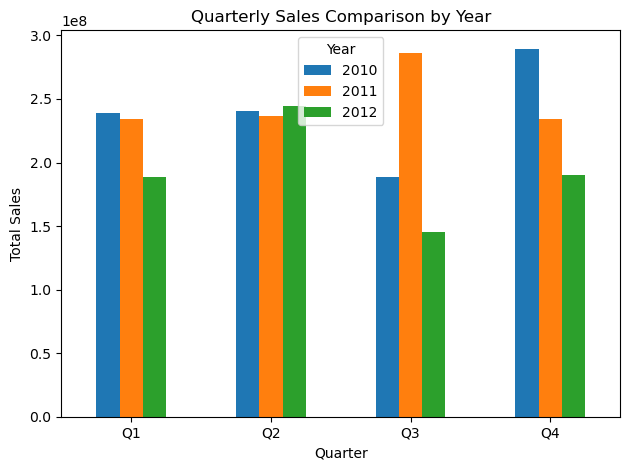

In [3]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Quarter'] = df['Date'].dt.to_period('Q')
df['Year'] = df['Date'].dt.year

quarterly_sales = df.groupby(['Year', 'Quarter'])['Weekly_Sales'].sum().reset_index()
quarterly_sales['Quarter_Label'] = quarterly_sales['Quarter'].astype(str).str[-2:]

pivot_quarters = quarterly_sales.pivot(index='Quarter_Label', columns='Year', values='Weekly_Sales')
pivot_quarters.index = ['Q1', 'Q2', 'Q3', 'Q4']

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
pivot_quarters.plot(kind='bar')
plt.title('Quarterly Sales Comparison by Year')
plt.ylabel('Total Sales')
plt.xlabel('Quarter')
plt.xticks(rotation=0)
plt.legend(title='Year')
plt.tight_layout()
plt.show()


In [4]:
# Convert date column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Define major and minor holiday dates
major_holidays = pd.to_datetime([
    '2010-11-26', '2010-12-31',
    '2011-11-25', '2011-12-30',
    '2012-11-23', '2012-12-25'
])

minor_holidays = pd.to_datetime([
    '2010-02-12', '2010-09-10',
    '2011-02-11', '2011-09-09',
    '2012-02-10', '2012-09-07'
])

# Tag holiday type
df['Holiday_Type'] = 'None'
df.loc[df['Date'].isin(minor_holidays), 'Holiday_Type'] = 'Minor'
df.loc[df['Date'].isin(major_holidays), 'Holiday_Type'] = 'Major'


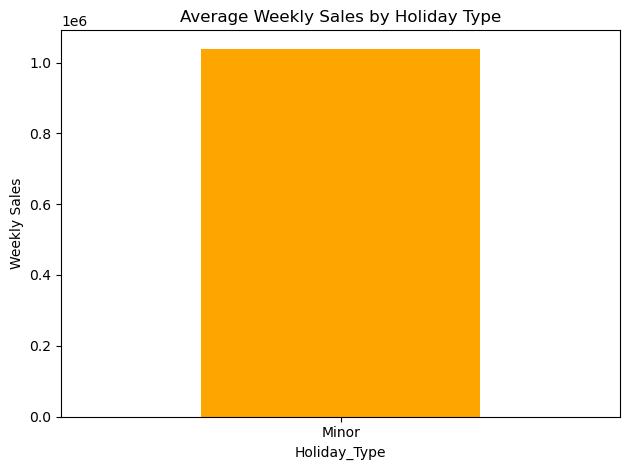

In [5]:
holiday_sales = df[df['Holiday_Type'] != 'None'].groupby('Holiday_Type')['Weekly_Sales'].mean()

# Plot
import matplotlib.pyplot as plt

holiday_sales.plot(kind='bar', color=['orange', 'red'])
plt.title('Average Weekly Sales by Holiday Type')
plt.ylabel('Weekly Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Define holiday dates
major_holidays = pd.to_datetime(['2010-11-26', '2010-12-25', '2011-11-25', '2011-12-25', '2012-11-23', '2012-12-25'])
minor_holidays = pd.to_datetime(['2010-02-12', '2010-09-10', '2011-02-11', '2011-09-09', '2012-02-10', '2012-09-07'])

# Tag holiday type
df['Holiday_Type'] = 'None'
df.loc[df['Date'].isin(minor_holidays), 'Holiday_Type'] = 'Minor'
df.loc[df['Date'].isin(major_holidays), 'Holiday_Type'] = 'Major'


/var/folders/c6/n9y59mk93xn8_nv5r6ts8ldw0000gn/T/ipykernel_12168/838868503.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=holiday_avg.index, y=holiday_avg.values, palette=['lightblue', 'orange', 'red'])


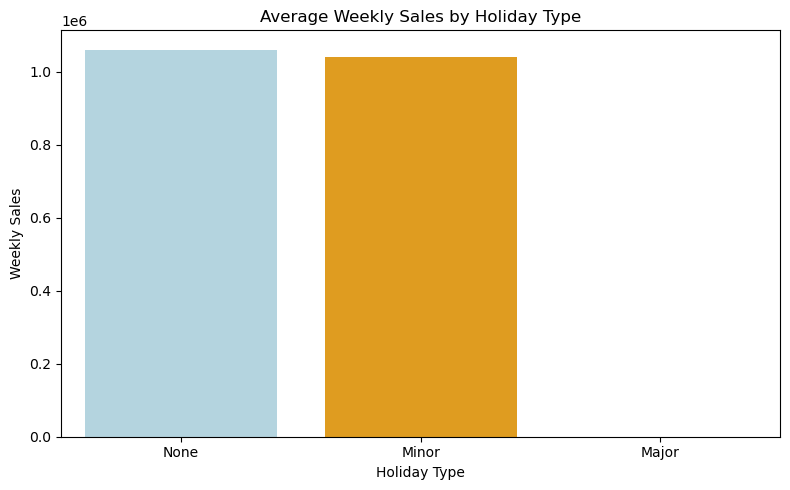

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by holiday type
holiday_avg = df.groupby('Holiday_Type')['Weekly_Sales'].mean().reindex(['None', 'Minor', 'Major'])

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=holiday_avg.index, y=holiday_avg.values, palette=['lightblue', 'orange', 'red'])
plt.title('Average Weekly Sales by Holiday Type')
plt.ylabel('Weekly Sales')
plt.xlabel('Holiday Type')
plt.tight_layout()
plt.show()
